# Chapter 3 - Deep Q-learning
### Deep Reinforcement Learning *in Action*

##### Listing 3.1

In [1]:
!git clone https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction.git
import os
os.chdir('DeepReinforcementLearningInAction/Chapter 3')
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Cloning into 'DeepReinforcementLearningInAction'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 264 (delta 12), reused 7 (delta 7), pack-reused 244 (from 3)
Receiving objects: 100% (264/264), 3.71 MiB | 7.75 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Using device: cuda


In [2]:
from Gridworld import Gridworld
game = Gridworld(size=4, mode='static')

In [3]:
game.display()

array([['+', '-', ' ', 'P'],
       [' ', 'W', ' ', ' '],
       [' ', ' ', ' ', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [4]:
game.makeMove('d')
game.makeMove('d')
game.makeMove('l')
game.display()

array([['+', '-', ' ', ' '],
       [' ', 'W', ' ', ' '],
       [' ', ' ', 'P', ' '],
       [' ', ' ', ' ', ' ']], dtype='<U2')

In [5]:
game.reward()

-1

In [6]:
game.board.render_np()

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [7]:
action_set = {
    0: 'u',
    1: 'd',
    2: 'l',
    3: 'r',
}

###### Dueling DQN

In [8]:
import numpy as np
import torch
from Gridworld import Gridworld
from IPython.display import clear_output
import random
from matplotlib import pylab as plt
import copy

l1 = 64
l2 = 150
l3 = 100
l4 = 4


class DuelingDQN(torch.nn.Module): # Dueling DQN Modified: Create Dueling DQN model class
    def __init__(self, l1=64, l2=150, l3=100, l4=4):
        super(DuelingDQN, self).__init__()

        # Dueling DQN Modified: Feature extraction layer
        self.fc1 = torch.nn.Linear(l1, l2)

        # Dueling DQN Modified: State Value branch (V)
        self.value_fc = torch.nn.Linear(l2, l3)
        self.value = torch.nn.Linear(l3, 1)

        # Dueling DQN Modified: Advantage branch (A)
        self.adv_fc = torch.nn.Linear(l2, l3)
        self.adv = torch.nn.Linear(l3, l4)

    def forward(self, x):
        x = torch.nn.functional.relu(self.fc1(x))

        v = torch.nn.functional.relu(self.value_fc(x))
        v = self.value(v)

        a = torch.nn.functional.relu(self.adv_fc(x))
        a = self.adv(a)

        # Dueling DQN Modified: Q(s,a) = V(s) + A(s,a) - mean(A)
        q = v + a - a.mean(dim=1, keepdim=True)
        return q

model = DuelingDQN(l1, l2, l3, l4).to(device) # Dueling DQN Modified: Initialize prediction network

model2 = copy.deepcopy(model).to(device) #A
model2.load_state_dict(model.state_dict()) #B

loss_fn = torch.nn.MSELoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

gamma = 0.9
epsilon = 0.3

In [9]:
from collections import deque
epochs = 5000
losses = []
mem_size = 1000
batch_size = 200
replay = deque(maxlen=mem_size)
max_moves = 50
h = 0
sync_freq = 1000 # DDQN Modified: Sync target network every 1000 steps
j=0
for i in range(epochs):
    game = Gridworld(size=4, mode='player')
    state1_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
    state1 = torch.from_numpy(state1_).float().to(device)
    status = 1
    mov = 0
    while(status == 1):
        j+=1
        mov += 1
        qval = model(state1)
        qval_ = qval.cpu().data.numpy()
        if (random.random() < epsilon):
            action_ = np.random.randint(0,4)
        else:
            action_ = np.argmax(qval_)

        action = action_set[action_]
        game.makeMove(action)
        state2_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        state2 = torch.from_numpy(state2_).float().to(device)
        reward = game.reward()
        done = True if reward > 0 else False
        exp =  (state1, action_, reward, state2, done)
        replay.append(exp) #H
        state1 = state2

        if len(replay) > batch_size:
            minibatch = random.sample(replay, batch_size)
            state1_batch = torch.cat([s1 for (s1,a,r,s2,d) in minibatch]).to(device)
            action_batch = torch.Tensor([a for (s1,a,r,s2,d) in minibatch]).to(device)
            reward_batch = torch.Tensor([r for (s1,a,r,s2,d) in minibatch]).to(device)
            state2_batch = torch.cat([s2 for (s1,a,r,s2,d) in minibatch]).to(device)
            done_batch = torch.Tensor([d for (s1,a,r,s2,d) in minibatch]).to(device)
            Q1 = model(state1_batch)
            with torch.no_grad():
                Q2_main = model(state2_batch) # DDQN Modified: Use Main Network
                action_next = torch.argmax(Q2_main, dim=1)  # DDQN Modified: Select best action a*
                Q2_target = model2(state2_batch) # DDQN Modified: Use Target Network

            Q2_val = Q2_target.gather(dim=1, index=action_next.unsqueeze(dim=1)).squeeze() # DDQN Modified: Compute score for a*
            Y = reward_batch + gamma * ((1-done_batch) * Q2_val)  # DDQN Modified: Compute target y_j
            X = Q1.gather(dim=1,index=action_batch.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            print(i, loss.item())
            clear_output(wait=True)
            optimizer.zero_grad()
            loss.backward()
            losses.append(loss.item())
            optimizer.step()

            if j % sync_freq == 0: #C
                model2.load_state_dict(model.state_dict())
        if reward != -1 or mov > max_moves:
            status = 0
            mov = 0

losses = np.array(losses)

#A Set the update frequency for synchronizing the target model parameters to the main DQN
#B Use the target network to get the maiximum Q-value for the next state
#C Copy the main model parameters to the target network

4999 0.0001772459945641458


Text(0, 0.5, 'Loss')

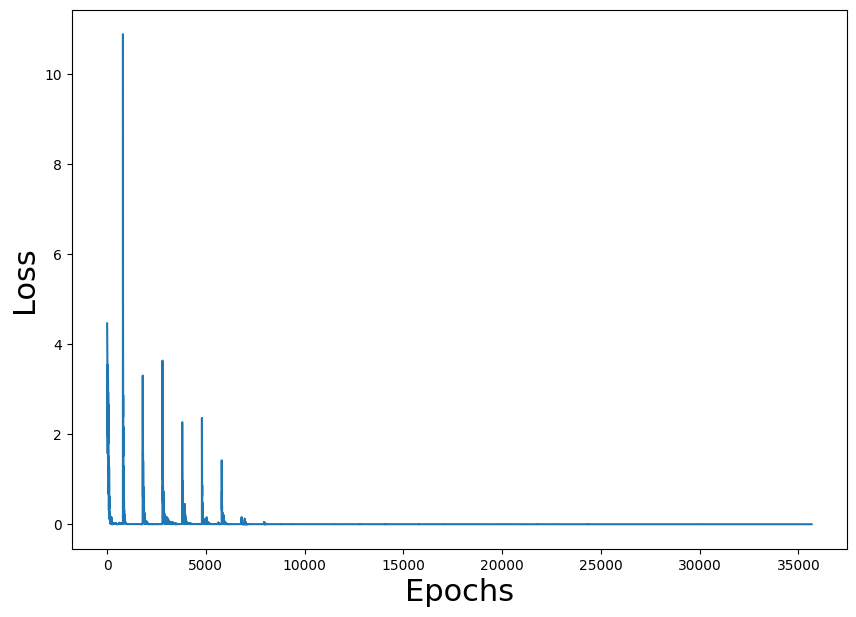

In [10]:
plt.figure(figsize=(10,7))
plt.plot(losses)
plt.xlabel("Epochs",fontsize=22)
plt.ylabel("Loss",fontsize=22)

In [11]:
def test_model(model, mode='static', display=True):
    i = 0
    test_game = Gridworld(mode=mode)
    state_ = test_game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
    state = torch.from_numpy(state_).float().to(device)
    if display:
        print("Initial State:")
        print(test_game.display())
    status = 1
    while(status == 1): #A
        qval = model(state)
        qval_ = qval.cpu().data.numpy()
        action_ = np.argmax(qval_) #B
        action = action_set[action_]
        if display:
            print('Move #: %s; Taking action: %s' % (i, action))
        test_game.makeMove(action)
        state_ = test_game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
        state = torch.from_numpy(state_).float().to(device)
        if display:
            print(test_game.display())
        reward = test_game.reward()
        if reward != -1:
            if reward > 0:
                status = 2
                if display:
                    print("Game won! Reward: %s" % (reward,))
            else:
                status = 0
                if display:
                    print("Game LOST. Reward: %s" % (reward,))
        i += 1
        if (i > 15):
            if display:
                print("Game lost; too many moves.")
            break

    win = True if status == 2 else False
    return win

In [12]:
max_games = 1000
wins = 0
for i in range(max_games):
    win = test_model(model, mode='player', display=False)
    if win:
        wins += 1
win_perc = float(wins) / float(max_games)
print("Games played: {0}, # of wins: {1}".format(max_games,wins))
print("Win percentage: {}%".format(100.0*win_perc))

Games played: 1000, # of wins: 1000
Win percentage: 100.0%
